## Exploratory Data Analysis

In [1]:
import pandas as pd

df = pd.read_csv('../datasets/raw/raw.csv')
df.head(n=10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    str    
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), str(1)
memory usage: 91.5 KB


In [3]:
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


In [4]:
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [5]:
df.columns

Index(['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='str')

## Target Feature: Count

In [6]:
# dropping redundant features

df.drop(columns=["instant"], inplace=True)

In [7]:
# casual and registered will cause leakage 

df.drop(columns=['casual', 'registered'], inplace=True)
df.head()

,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985
1,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801
2,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349
3,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562
4,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600


In [8]:
# dteday is a str, lets handle it

df["dteday"] = pd.to_datetime(df["dteday"])

df["dayofweek"] = df["dteday"].dt.dayofweek
df["month"] = df["dteday"].dt.month
df["year"] = df["dteday"].dt.year

df.drop(columns=['dteday'], inplace=True)

df.head()

,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,dayofweek,month,year
0,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985,5,1,2011
1,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801,6,1,2011
2,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349,0,1,2011
3,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562,1,1,2011
4,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600,2,1,2011


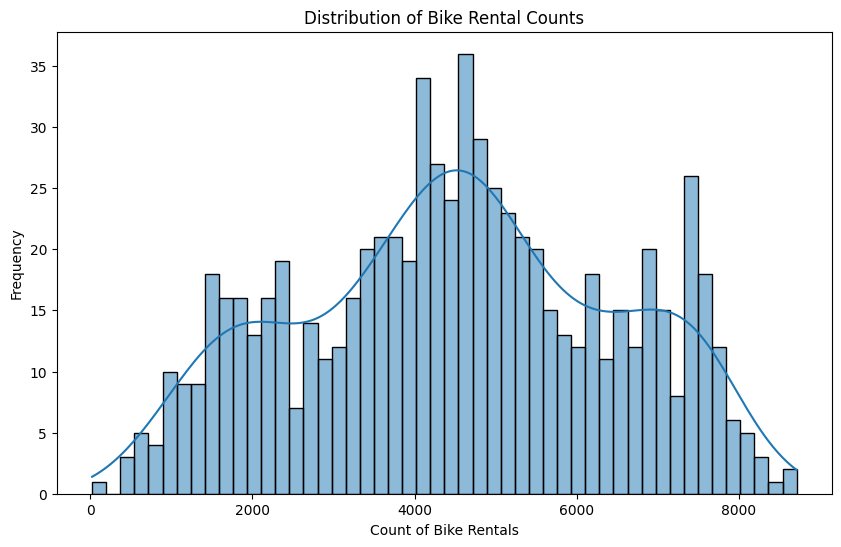

In [9]:
## checking target distribution

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['cnt'], bins=50, kde=True)
plt.title('Distribution of Bike Rental Counts')
plt.xlabel('Count of Bike Rentals')
plt.ylabel('Frequency')
plt.show()

In [10]:
## observation:
#1. distribution almost bell shaped with a slight right tail, overall no extreme skew
#2. log transformation not required

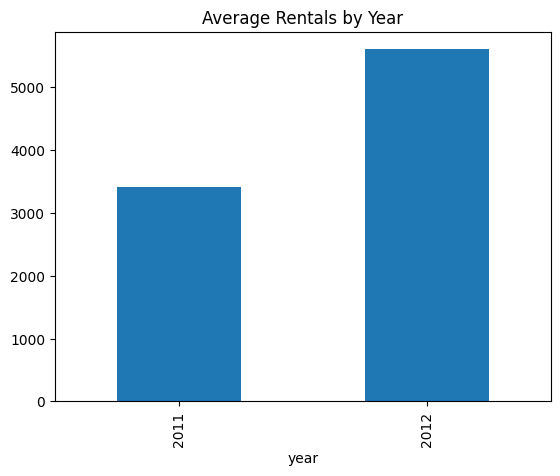

In [11]:
year_avg = df.groupby("year")["cnt"].mean()

year_avg.plot(kind="bar")
plt.title("Average Rentals by Year")
plt.show()

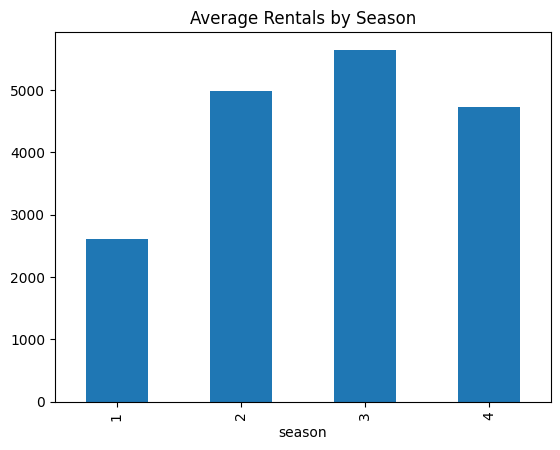

In [12]:
season_avg = df.groupby("season")["cnt"].mean()

season_avg.plot(kind="bar")
plt.title("Average Rentals by Season")
plt.show()

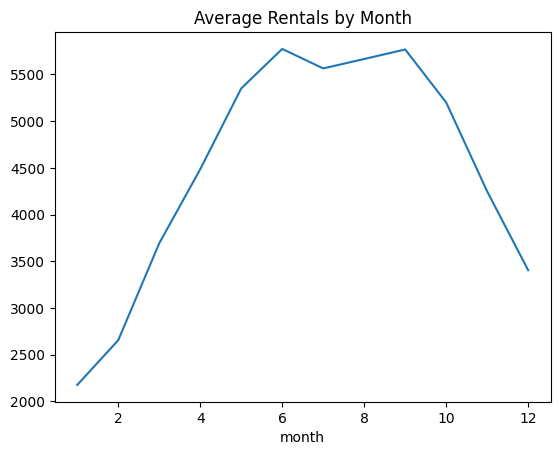

In [13]:
monthly_avg = df.groupby("month")["cnt"].mean()

monthly_avg.plot()
plt.title("Average Rentals by Month")
plt.show()

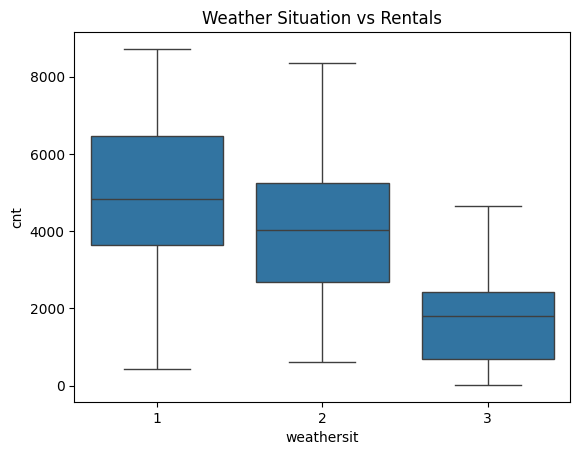

In [14]:
sns.boxplot(x="weathersit", y="cnt", data=df)
plt.title("Weather Situation vs Rentals")
plt.show()

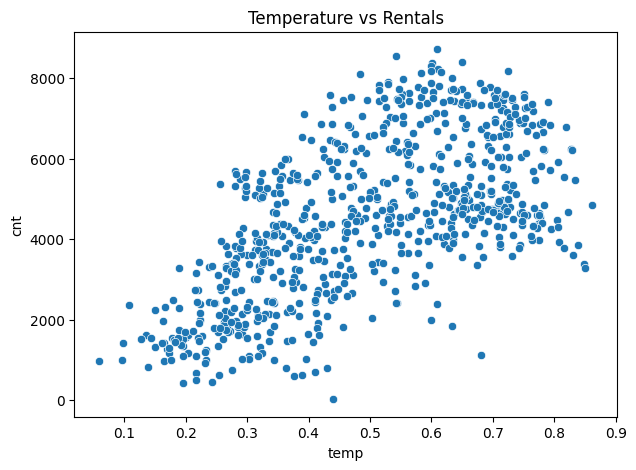

In [15]:
plt.figure(figsize=(7,5))
sns.scatterplot(x="temp", y="cnt", data=df)
plt.title("Temperature vs Rentals")
plt.show()

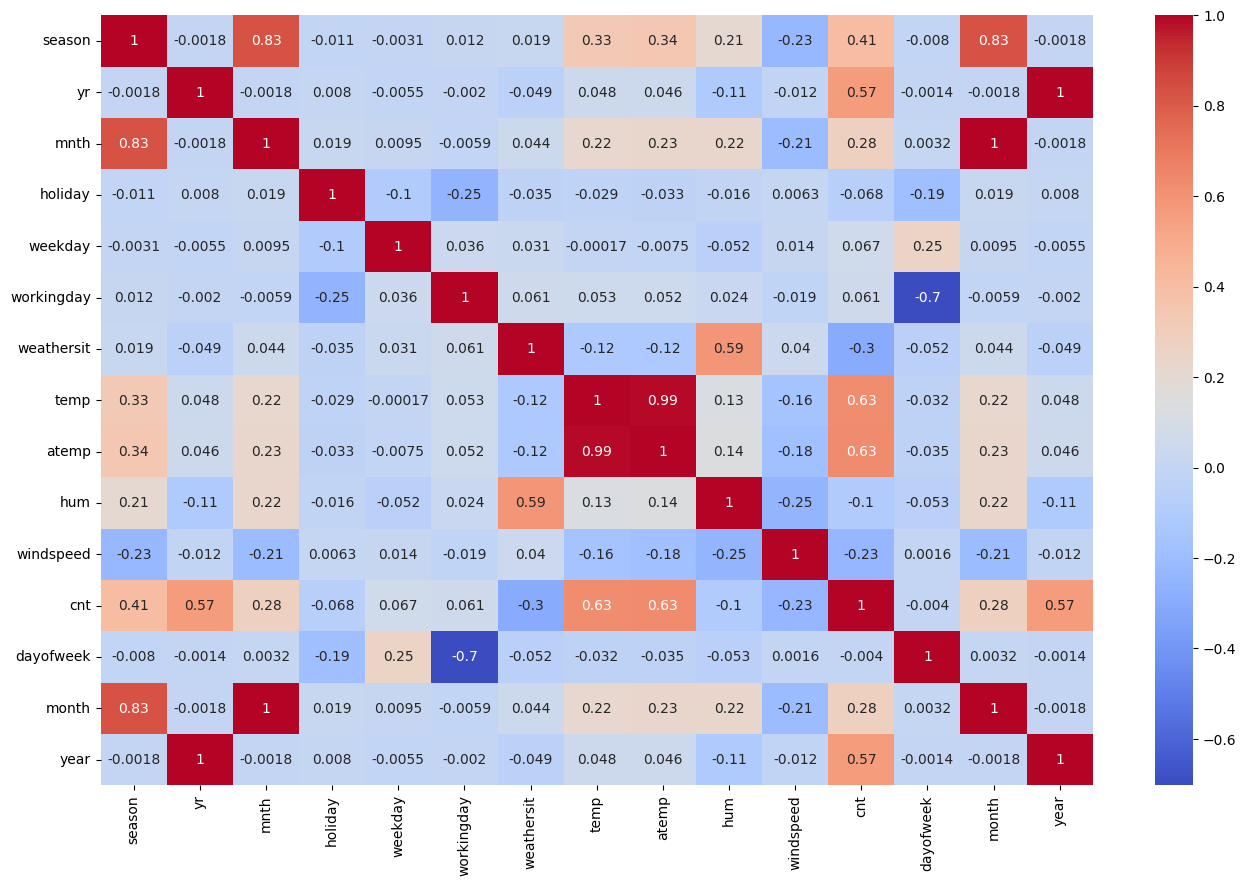

In [16]:
plt.figure(figsize=(16,10))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.show()

In [17]:
df.drop(columns=['yr', 'mnth'], inplace=True)
df.head()

,season,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt,dayofweek,month,year
0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,985,5,1,2011
1,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,801,6,1,2011
2,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,1349,0,1,2011
3,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,1562,1,1,2011
4,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,1600,2,1,2011


In [18]:
df.drop(columns=['atemp','weekday'], inplace=True)

In [19]:
## observations:

#1. year and month are not required as we have already extracted year and month from dteday
#2. The target variable 'cnt' is highly correlated with 'temp', 'atemp', and 'hum'. This suggests that temperature and humidity are strong predictors of bike demand.
#3. 'windspeed' has a moderate negative correlation with 'cnt', indicating that higher wind speeds may reduce bike rentals.
#4. 'season' and 'weathersit' also show some correlation with 'cnt', suggesting that seasonal changes and weather conditions affect bike demand.
#5. 'holiday' and 'workingday' have low correlation with 'cnt', indicating that they may not be strong predictors of bike demand in this dataset.
#6. 'dayofweek' has a very low correlation with 'cnt', suggesting that the day of the week may not significantly influence bike rentals in this dataset.

In [20]:
processed_data = df.copy()
processed_data.to_csv('../datasets/processed/processed.csv', index=False)